In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('Train.csv')
df_test = pd.read_csv('Test.csv')

In [3]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18594 entries, 0 to 18593
Data columns (total 15 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           18594 non-null  object 
 1   customer_id                  18594 non-null  int64  
 2   country_id                   18594 non-null  object 
 3   tbl_loan_id                  18594 non-null  int64  
 4   lender_id                    18594 non-null  int64  
 5   loan_type                    18594 non-null  object 
 6   Total_Amount                 18594 non-null  float64
 7   Total_Amount_to_Repay        18594 non-null  float64
 8   disbursement_date            18594 non-null  object 
 9   due_date                     18594 non-null  object 
 10  duration                     18594 non-null  int64  
 11  New_versus_Repeat            18594 non-null  object 
 12  Amount_Funded_By_Lender      18594 non-null  float64
 13  Lender_portion_F

In [4]:
df

,ID,customer_id,country_id,tbl_loan_id,lender_id,loan_type,Total_Amount,Total_Amount_to_Repay,disbursement_date,due_date,duration,New_versus_Repeat,Amount_Funded_By_Lender,Lender_portion_Funded,Lender_portion_to_be_repaid,target
0,ID_266671248032267278,266671,Kenya,248032,267278,Type_1,8448.0,8448.0,2022-08-30,2022-09-06,7,Repeat Loan,120.85,0.014305,121.0,0
1,ID_248919228515267278,248919,Kenya,228515,267278,Type_1,25895.0,25979.0,2022-07-30,2022-08-06,7,Repeat Loan,7768.50,0.300000,7794.0,0
2,ID_308486370501251804,308486,Kenya,370501,251804,Type_7,6900.0,7142.0,2024-09-06,2024-09-13,7,Repeat Loan,1380.00,0.200000,1428.0,0
3,ID_266004285009267278,266004,Kenya,285009,267278,Type_1,8958.0,9233.0,2022-10-20,2022-10-27,7,Repeat Loan,2687.40,0.300000,2770.0,0
4,ID_253803305312267278,253803,Kenya,305312,267278,Type_1,4564.0,4728.0,2022-11-28,2022-12-05,7,Repeat Loan,1369.20,0.300000,1418.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68649,ID_244559228408267278,244559,Kenya,228408,267278,Type_1,1460.0,1515.0,2022-07-30,2022-08-06,7,Repeat Loan,438.00,0.300000,455.0,0
68650,ID_260062217784267278,260062,Kenya,217784,267278,Type_1,5029.0,5116.0,2022-07-16,2022-07-23,7,Repeat Loan,1508.70,0.300000,1535.0,0
68651,ID_259137216701267278,259137,Kenya,216701,267278,Type_1,5289.0,5289.0,2022-07-15,2022-07-22,7,Repeat Loan,1586.70,0.300000,1587.0,0
68652,ID_266801303201267278,266801,Kenya,303201,267278,Type_1,3334.0,3334.0,2022-11-23,2022-11-30,7,Repeat Loan,741.09,0.222283,741.0,0


In [5]:
df_test

,ID,customer_id,country_id,tbl_loan_id,lender_id,loan_type,Total_Amount,Total_Amount_to_Repay,disbursement_date,due_date,duration,New_versus_Repeat,Amount_Funded_By_Lender,Lender_portion_Funded,Lender_portion_to_be_repaid
0,ID_269404226088267278,269404,Kenya,226088,267278,Type_1,1919.00,1989.00,2022-07-27,2022-08-03,7,Repeat Loan,575.70,0.300000,597.00
1,ID_255356300042267278,255356,Kenya,300042,267278,Type_1,2138.00,2153.00,2022-11-16,2022-11-23,7,Repeat Loan,0.00,0.000000,0.00
2,ID_257026243764267278,257026,Kenya,243764,267278,Type_1,8254.00,8304.00,2022-08-24,2022-08-31,7,Repeat Loan,207.00,0.025079,208.00
3,ID_264617299409267278,264617,Kenya,299409,267278,Type_1,3379.00,3379.00,2022-11-15,2022-11-22,7,Repeat Loan,1013.70,0.300000,1014.00
4,ID_247613296713267278,247613,Kenya,296713,267278,Type_1,120.00,120.00,2022-11-10,2022-11-17,7,Repeat Loan,36.00,0.300000,36.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18589,ID_297596365331297183,297596,Ghana,365331,297183,Type_3,1730.41,1782.32,2023-02-09,2023-02-16,7,Repeat Loan,269.41,0.155689,279.77
18590,ID_259715231897267278,259715,Kenya,231897,267278,Type_1,1534.00,1534.00,2022-08-04,2022-08-11,7,Repeat Loan,460.20,0.300000,460.00
18591,ID_296701364008297183,296701,Ghana,364008,297183,Type_3,1372.21,1413.30,2022-06-23,2022-06-30,7,Repeat Loan,178.67,0.130208,178.67
18592,ID_268271242864267278,268271,Kenya,242864,267278,Type_1,5608.00,5781.00,2022-08-23,2022-08-30,7,Repeat Loan,0.00,0.000000,0.00


In [6]:
df_test.rename(columns={'ID':'id', 'Total_Amount':'total_amount', 'Total_Amount_to_Repay':'total_amount_to_repay', 'New_versus_Repeat':'new_versus_repeat',  
                   'Amount_Funded_By_Lender':'amount_funded_by_lender', 'Lender_portion_Funded':'lender_portion_funded',
                   'Lender_portion_to_be_repaid':'lender_portion_to_be_repaid'}, inplace=True)

In [7]:
df.rename(columns={'ID':'id', 'Total_Amount':'total_amount', 'Total_Amount_to_Repay':'total_amount_to_repay', 'New_versus_Repeat':'new_versus_repeat',  
                   'Amount_Funded_By_Lender':'amount_funded_by_lender', 'Lender_portion_Funded':'lender_portion_funded',
                   'Lender_portion_to_be_repaid':'lender_portion_to_be_repaid'}, inplace=True)

In [8]:
df_test['target'] = None

In [9]:
df['source'] = 'Train'
df_test['source'] = 'Test'

In [10]:
df_combined = pd.concat([df, df_test], ignore_index=True)

In [11]:
df_combined.head()

,id,customer_id,country_id,tbl_loan_id,lender_id,loan_type,total_amount,total_amount_to_repay,disbursement_date,due_date,duration,new_versus_repeat,amount_funded_by_lender,lender_portion_funded,lender_portion_to_be_repaid,target,source
0,ID_266671248032267278,266671,Kenya,248032,267278,Type_1,8448.0,8448.0,2022-08-30,2022-09-06,7,Repeat Loan,120.85,0.014305,121.0,0,Train
1,ID_248919228515267278,248919,Kenya,228515,267278,Type_1,25895.0,25979.0,2022-07-30,2022-08-06,7,Repeat Loan,7768.50,0.300000,7794.0,0,Train
2,ID_308486370501251804,308486,Kenya,370501,251804,Type_7,6900.0,7142.0,2024-09-06,2024-09-13,7,Repeat Loan,1380.00,0.200000,1428.0,0,Train
3,ID_266004285009267278,266004,Kenya,285009,267278,Type_1,8958.0,9233.0,2022-10-20,2022-10-27,7,Repeat Loan,2687.40,0.300000,2770.0,0,Train
4,ID_253803305312267278,253803,Kenya,305312,267278,Type_1,4564.0,4728.0,2022-11-28,2022-12-05,7,Repeat Loan,1369.20,0.300000,1418.0,0,Train


In [12]:
economic_data = pd.read_csv('economic_indicators.csv')
economic_data1 = economic_data.query("Country == 'Kenya'  or Country == 'Ghana'").reset_index(drop=True)
economic_data1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18 entries, 0 to 17
Data columns (total 25 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Country    18 non-null     object 
 1   Indicator  18 non-null     object 
 2   YR2001     15 non-null     float64
 3   YR2002     15 non-null     float64
 4   YR2003     15 non-null     float64
 5   YR2004     15 non-null     float64
 6   YR2005     15 non-null     float64
 7   YR2006     15 non-null     float64
 8   YR2007     15 non-null     float64
 9   YR2008     15 non-null     float64
 10  YR2009     15 non-null     float64
 11  YR2010     15 non-null     float64
 12  YR2011     15 non-null     float64
 13  YR2012     15 non-null     float64
 14  YR2013     15 non-null     float64
 15  YR2014     15 non-null     float64
 16  YR2015     13 non-null     float64
 17  YR2016     13 non-null     float64
 18  YR2017     13 non-null     float64
 19  YR2018     13 non-null     float64
 20  YR2019     1

In [13]:
economic_data1.columns

Index(['Country', 'Indicator', 'YR2001', 'YR2002', 'YR2003', 'YR2004',
       'YR2005', 'YR2006', 'YR2007', 'YR2008', 'YR2009', 'YR2010', 'YR2011',
       'YR2012', 'YR2013', 'YR2014', 'YR2015', 'YR2016', 'YR2017', 'YR2018',
       'YR2019', 'YR2020', 'YR2021', 'YR2022', 'YR2023'],
      dtype='object')

In [14]:
economic_data1.rename(columns={'Country':'country', 'Indicator':'indicator', 'YR2001':'2001', 'YR2002':'2002', 'YR2003':'2003', 'YR2004':'2004', 'YR2005':'2005', 'YR2006':'2006','YR2007':'2007','YR2008':'2008','YR2009':'2009', 'YR2010':'2010', 'YR2011':'2011', 'YR2012':'2012', 'YR2013':'2013', 'YR2014':'2014', 'YR2015':'2015', 'YR2016':'2016', 'YR2017':'2017', 'YR2018':'2018', 'YR2019':'2019', 'YR2020':'2020', 'YR2021':'2021', 'YR2022':'2022', 'YR2023':'2023'}, inplace=True)
economic_data1.head(3)

,country,indicator,2001,2002,2003,2004,2005,2006,2007,2008,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
0,Ghana,"Inflation, consumer prices (annual %)",41.509496,9.360932,29.772980,18.042739,15.438992,11.679184,10.734267,16.494640,...,15.489616,17.149970,17.454635,12.371922,7.808765,7.143640,9.887290,9.971089,31.255895,38.106966
1,Kenya,"Inflation, consumer prices (annual %)",5.738598,1.961308,9.815691,11.624036,10.312778,14.453734,9.758880,26.239817,...,6.878155,6.582154,6.297250,8.005650,4.689806,5.239638,5.405162,6.107936,7.659863,7.671396
2,Ghana,"Official exchange rate (LCU per US$, period av...",0.716305,0.792417,0.866764,0.899495,0.905209,0.915107,0.932619,1.052275,...,2.896575,3.714642,3.909817,4.350533,4.585325,5.217367,5.595708,5.805700,8.272400,11.020408


In [15]:
df_combined['disbursement_date'] = pd.to_datetime(df_combined['disbursement_date'])
df_combined['disbursement_year'] = df_combined['disbursement_date'].dt.year
df_combined['disbursement_date'] = df_combined['disbursement_date'].dt.strftime('%Y-%m-%d')

In [16]:
df_combined.head(6)

,id,customer_id,country_id,tbl_loan_id,lender_id,loan_type,total_amount,total_amount_to_repay,disbursement_date,due_date,duration,new_versus_repeat,amount_funded_by_lender,lender_portion_funded,lender_portion_to_be_repaid,target,source,disbursement_year
0,ID_266671248032267278,266671,Kenya,248032,267278,Type_1,8448.0,8448.0,2022-08-30,2022-09-06,7,Repeat Loan,120.85,0.014305,121.0,0,Train,2022
1,ID_248919228515267278,248919,Kenya,228515,267278,Type_1,25895.0,25979.0,2022-07-30,2022-08-06,7,Repeat Loan,7768.50,0.300000,7794.0,0,Train,2022
2,ID_308486370501251804,308486,Kenya,370501,251804,Type_7,6900.0,7142.0,2024-09-06,2024-09-13,7,Repeat Loan,1380.00,0.200000,1428.0,0,Train,2024
3,ID_266004285009267278,266004,Kenya,285009,267278,Type_1,8958.0,9233.0,2022-10-20,2022-10-27,7,Repeat Loan,2687.40,0.300000,2770.0,0,Train,2022
4,ID_253803305312267278,253803,Kenya,305312,267278,Type_1,4564.0,4728.0,2022-11-28,2022-12-05,7,Repeat Loan,1369.20,0.300000,1418.0,0,Train,2022
5,ID_265607284433267278,265607,Kenya,284433,267278,Type_1,4325.0,4325.0,2022-10-19,2022-10-26,7,Repeat Loan,1297.50,0.300000,1298.0,0,Train,2022


In [17]:
df_combined = df_combined[['id', 'customer_id', 'country_id', 'disbursement_year', 'tbl_loan_id', 'lender_id', 'loan_type', 'total_amount', 
                           'total_amount_to_repay', 'disbursement_date', 'due_date', 'duration', 'new_versus_repeat', 'amount_funded_by_lender', 
                           'lender_portion_funded', 'lender_portion_to_be_repaid', 'target', 'source']]
df_combined.head(8)

,id,customer_id,country_id,disbursement_year,tbl_loan_id,lender_id,loan_type,total_amount,total_amount_to_repay,disbursement_date,due_date,duration,new_versus_repeat,amount_funded_by_lender,lender_portion_funded,lender_portion_to_be_repaid,target,source
0,ID_266671248032267278,266671,Kenya,2022,248032,267278,Type_1,8448.0,8448.0,2022-08-30,2022-09-06,7,Repeat Loan,120.85,0.014305,121.0,0,Train
1,ID_248919228515267278,248919,Kenya,2022,228515,267278,Type_1,25895.0,25979.0,2022-07-30,2022-08-06,7,Repeat Loan,7768.50,0.300000,7794.0,0,Train
2,ID_308486370501251804,308486,Kenya,2024,370501,251804,Type_7,6900.0,7142.0,2024-09-06,2024-09-13,7,Repeat Loan,1380.00,0.200000,1428.0,0,Train
3,ID_266004285009267278,266004,Kenya,2022,285009,267278,Type_1,8958.0,9233.0,2022-10-20,2022-10-27,7,Repeat Loan,2687.40,0.300000,2770.0,0,Train
4,ID_253803305312267278,253803,Kenya,2022,305312,267278,Type_1,4564.0,4728.0,2022-11-28,2022-12-05,7,Repeat Loan,1369.20,0.300000,1418.0,0,Train
5,ID_265607284433267278,265607,Kenya,2022,284433,267278,Type_1,4325.0,4325.0,2022-10-19,2022-10-26,7,Repeat Loan,1297.50,0.300000,1298.0,0,Train
6,ID_261844305920267278,261844,Kenya,2022,305920,267278,Type_1,6735.0,6735.0,2022-11-29,2022-12-06,7,Repeat Loan,2020.50,0.300000,2021.0,0,Train
7,ID_265488287698267278,265488,Kenya,2022,287698,267278,Type_1,1540.0,1562.0,2022-10-25,2022-11-01,7,Repeat Loan,462.00,0.300000,469.0,0,Train


In [18]:
df_melted = economic_data1.melt(id_vars=['country', 'indicator'], var_name='year', value_name='value')
df_melted

,country,indicator,year,value
0,Ghana,"Inflation, consumer prices (annual %)",2001,41.509496
1,Kenya,"Inflation, consumer prices (annual %)",2001,5.738598
2,Ghana,"Official exchange rate (LCU per US$, period av...",2001,0.716305
3,Kenya,"Official exchange rate (LCU per US$, period av...",2001,78.563195
4,Ghana,Real interest rate (%),2001,NaN
...,...,...,...,...
409,Kenya,Interest rate spread (lending rate minus depos...,2023,4.420812
410,Ghana,Fossil fuel energy consumption (% of total),2023,NaN
411,Kenya,Fossil fuel energy consumption (% of total),2023,NaN
412,Ghana,Unemployment rate,2023,3.079000


In [19]:
df_combined['disbursement_year'].unique()

array([2022, 2024, 2023, 2021])

In [20]:
df_melted = df_melted[df_melted['year'].isin(df_combined['disbursement_year'].astype(str))].reset_index(drop=True)
df_melted.head()

,country,indicator,year,value
0,Ghana,"Inflation, consumer prices (annual %)",2021,9.971089
1,Kenya,"Inflation, consumer prices (annual %)",2021,6.107936
2,Ghana,"Official exchange rate (LCU per US$, period av...",2021,5.805700
3,Kenya,"Official exchange rate (LCU per US$, period av...",2021,109.637747
4,Ghana,Real interest rate (%),2021,NaN


In [21]:
df_pivoted = df_melted.pivot_table(
    index=['country', 'year'], 
    columns='indicator', 
    values='value'
).reset_index()
df_pivoted

indicator,country,year,Average precipitation in depth (mm per year),Deposit interest rate (%),"Inflation, consumer prices (annual %)","Interest rate spread (lending rate minus deposit rate, %)",Lending interest rate (%),"Official exchange rate (LCU per US$, period average)",Real interest rate (%),Unemployment rate
0,Ghana,2021,1187.0,11.500000,9.971089,NaN,NaN,5.805700,NaN,3.338
1,Ghana,2022,NaN,12.052083,31.255895,NaN,NaN,8.272400,NaN,3.084
2,Ghana,2023,NaN,11.416667,38.106966,NaN,NaN,11.020408,NaN,3.079
3,Kenya,2021,630.0,6.686974,6.107936,5.393025,12.079998,109.637747,7.427581,5.693
4,Kenya,2022,NaN,7.145176,7.659863,5.190665,12.335841,117.865989,5.968447,5.805
5,Kenya,2023,NaN,9.167690,7.671396,4.420812,13.588502,139.846384,6.546517,5.682


In [22]:
average_precipitation_values = {
    'Ghana': 1187,
    'Kenya': 630
}

df_pivoted['Average precipitation in depth (mm per year)'] = df_pivoted.apply(
    lambda row: average_precipitation_values[row['country']]
    if pd.isna(row['Average precipitation in depth (mm per year)']) else row['Average precipitation in depth (mm per year)'],
    axis=1
)

print(df_pivoted[['country', 'year', 'Average precipitation in depth (mm per year)']])

indicator country  year  Average precipitation in depth (mm per year)
0           Ghana  2021                                        1187.0
1           Ghana  2022                                        1187.0
2           Ghana  2023                                        1187.0
3           Kenya  2021                                         630.0
4           Kenya  2022                                         630.0
5           Kenya  2023                                         630.0


In [23]:
# Ensure the 'year' column is of integer type
df_pivoted['year'] = pd.to_numeric(df_pivoted['year'], errors='coerce').astype('Int64')  # Handles NaN safely

In [24]:
lending_interest_rate_ghana = {
    2021: 14.5,
    2022: 27.0,
    2023: 30.0,
    2024: 30.0
}

# Lending interest rate (only for Ghana)
df_pivoted['Lending interest rate (%)'] = df_pivoted.apply(
    lambda row: lending_interest_rate_ghana[row['year']]
    if row['country'] == 'Ghana' and pd.isna(row['Lending interest rate (%)']) else row['Lending interest rate (%)'],
    axis=1
)

df_pivoted

indicator,country,year,Average precipitation in depth (mm per year),Deposit interest rate (%),"Inflation, consumer prices (annual %)","Interest rate spread (lending rate minus deposit rate, %)",Lending interest rate (%),"Official exchange rate (LCU per US$, period average)",Real interest rate (%),Unemployment rate
0,Ghana,2021,1187.0,11.500000,9.971089,NaN,14.500000,5.805700,NaN,3.338
1,Ghana,2022,1187.0,12.052083,31.255895,NaN,27.000000,8.272400,NaN,3.084
2,Ghana,2023,1187.0,11.416667,38.106966,NaN,30.000000,11.020408,NaN,3.079
3,Kenya,2021,630.0,6.686974,6.107936,5.393025,12.079998,109.637747,7.427581,5.693
4,Kenya,2022,630.0,7.145176,7.659863,5.190665,12.335841,117.865989,5.968447,5.805
5,Kenya,2023,630.0,9.167690,7.671396,4.420812,13.588502,139.846384,6.546517,5.682


In [25]:
missing_2024 = pd.DataFrame({
    'country': ['Ghana', 'Kenya'],
    'year': [2024, 2024]
})

missing_2024['Lending interest rate (%)'] = [30.0, 17.15]

for col in df_pivoted.columns:
    if col not in missing_2024.columns:
        missing_2024[col] = None 

df_pivoted = pd.concat([df_pivoted, missing_2024], ignore_index=True)
df_pivoted

C:\Users\Lamerck\AppData\Local\Temp\ipykernel_5600\3025294171.py:12: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_pivoted = pd.concat([df_pivoted, missing_2024], ignore_index=True)


,country,year,Average precipitation in depth (mm per year),Deposit interest rate (%),"Inflation, consumer prices (annual %)","Interest rate spread (lending rate minus deposit rate, %)",Lending interest rate (%),"Official exchange rate (LCU per US$, period average)",Real interest rate (%),Unemployment rate
0,Ghana,2021,1187.0,11.500000,9.971089,NaN,14.500000,5.805700,NaN,3.338
1,Ghana,2022,1187.0,12.052083,31.255895,NaN,27.000000,8.272400,NaN,3.084
2,Ghana,2023,1187.0,11.416667,38.106966,NaN,30.000000,11.020408,NaN,3.079
3,Kenya,2021,630.0,6.686974,6.107936,5.393025,12.079998,109.637747,7.427581,5.693
4,Kenya,2022,630.0,7.145176,7.659863,5.190665,12.335841,117.865989,5.968447,5.805
5,Kenya,2023,630.0,9.167690,7.671396,4.420812,13.588502,139.846384,6.546517,5.682
6,Ghana,2024,NaN,NaN,NaN,NaN,30.000000,NaN,NaN,NaN
7,Kenya,2024,NaN,NaN,NaN,NaN,17.150000,NaN,NaN,NaN


In [26]:
average_precipitation_values = {
    'Ghana': 1187,
    'Kenya': 630
}

df_pivoted['Average precipitation in depth (mm per year)'] = df_pivoted.apply(
    lambda row: average_precipitation_values[row['country']]
    if pd.isna(row['Average precipitation in depth (mm per year)']) else row['Average precipitation in depth (mm per year)'],
    axis=1
)

df_pivoted

,country,year,Average precipitation in depth (mm per year),Deposit interest rate (%),"Inflation, consumer prices (annual %)","Interest rate spread (lending rate minus deposit rate, %)",Lending interest rate (%),"Official exchange rate (LCU per US$, period average)",Real interest rate (%),Unemployment rate
0,Ghana,2021,1187.0,11.500000,9.971089,NaN,14.500000,5.805700,NaN,3.338
1,Ghana,2022,1187.0,12.052083,31.255895,NaN,27.000000,8.272400,NaN,3.084
2,Ghana,2023,1187.0,11.416667,38.106966,NaN,30.000000,11.020408,NaN,3.079
3,Kenya,2021,630.0,6.686974,6.107936,5.393025,12.079998,109.637747,7.427581,5.693
4,Kenya,2022,630.0,7.145176,7.659863,5.190665,12.335841,117.865989,5.968447,5.805
5,Kenya,2023,630.0,9.167690,7.671396,4.420812,13.588502,139.846384,6.546517,5.682
6,Ghana,2024,1187.0,NaN,NaN,NaN,30.000000,NaN,NaN,NaN
7,Kenya,2024,630.0,NaN,NaN,NaN,17.150000,NaN,NaN,NaN


In [27]:
# Update Deposit interest rate (%)
df_pivoted.loc[(df_pivoted['country'] == 'Ghana') & (df_pivoted['year'] == 2024), 'Deposit interest rate (%)'] = (
    df_pivoted.loc[(df_pivoted['country'] == 'Ghana') & (df_pivoted['year'].isin([2021, 2022, 2023])), 'Deposit interest rate (%)'].mean()
)
df_pivoted.loc[(df_pivoted['country'] == 'Kenya') & (df_pivoted['year'] == 2024), 'Deposit interest rate (%)'] = 10.73

# Update Inflation, consumer prices (annual %)
df_pivoted.loc[(df_pivoted['country'] == 'Ghana') & (df_pivoted['year'] == 2024), 'Inflation, consumer prices (annual %)'] = 21.6
df_pivoted.loc[(df_pivoted['country'] == 'Kenya') & (df_pivoted['year'] == 2024), 'Inflation, consumer prices (annual %)'] = 5.0

# Official exchange rate (LCU per US$, period average)
df_pivoted.loc[(df_pivoted['country'] == 'Ghana') & (df_pivoted['year'] == 2024), 'Official exchange rate (LCU per US$, period average)'] = 15.983
df_pivoted.loc[(df_pivoted['country'] == 'Kenya') & (df_pivoted['year'] == 2024), 'Official exchange rate (LCU per US$, period average)'] = 129.239

# Unemployment rate
df_pivoted.loc[(df_pivoted['country'] == 'Ghana') & (df_pivoted['year'] == 2024), 'Unemployment rate'] = 3.167
df_pivoted.loc[(df_pivoted['country'] == 'Kenya') & (df_pivoted['year'] == 2024), 'Unemployment rate'] = 5.726


# Update Interest rate spread (lending rate minus deposit rate, %)
df_pivoted.loc[(df_pivoted['country'] == 'Ghana') & (df_pivoted['year'] == 2021), 'Interest rate spread (lending rate minus deposit rate, %)'] = 3.0
df_pivoted.loc[(df_pivoted['country'] == 'Ghana') & (df_pivoted['year'] == 2022), 'Interest rate spread (lending rate minus deposit rate, %)'] = 14.9479
df_pivoted.loc[(df_pivoted['country'] == 'Ghana') & (df_pivoted['year'] == 2023), 'Interest rate spread (lending rate minus deposit rate, %)'] = 18.5833
df_pivoted.loc[(df_pivoted['country'] == 'Ghana') & (df_pivoted['year'] == 2024), 'Interest rate spread (lending rate minus deposit rate, %)'] = 18.3438
df_pivoted.loc[(df_pivoted['country'] == 'Kenya') & (df_pivoted['year'] == 2024), 'Interest rate spread (lending rate minus deposit rate, %)'] = 6.42

# Update Real interest rate (%)
df_pivoted.loc[(df_pivoted['country'] == 'Ghana') & (df_pivoted['year'] == 2021), 'Real interest rate (%)'] = 4.52891
df_pivoted.loc[(df_pivoted['country'] == 'Ghana') & (df_pivoted['year'] == 2022), 'Real interest rate (%)'] = -4.25589
df_pivoted.loc[(df_pivoted['country'] == 'Ghana') & (df_pivoted['year'] == 2023), 'Real interest rate (%)'] = -8.10697
df_pivoted.loc[(df_pivoted['country'] == 'Ghana') & (df_pivoted['year'] == 2024), 'Real interest rate (%)'] = 8.400
df_pivoted.loc[(df_pivoted['country'] == 'Kenya') & (df_pivoted['year'] == 2024), 'Real interest rate (%)'] = 12.15


df_pivoted

,country,year,Average precipitation in depth (mm per year),Deposit interest rate (%),"Inflation, consumer prices (annual %)","Interest rate spread (lending rate minus deposit rate, %)",Lending interest rate (%),"Official exchange rate (LCU per US$, period average)",Real interest rate (%),Unemployment rate
0,Ghana,2021,1187.0,11.500000,9.971089,3.000000,14.500000,5.805700,4.528910,3.338
1,Ghana,2022,1187.0,12.052083,31.255895,14.947900,27.000000,8.272400,-4.255890,3.084
2,Ghana,2023,1187.0,11.416667,38.106966,18.583300,30.000000,11.020408,-8.106970,3.079
3,Kenya,2021,630.0,6.686974,6.107936,5.393025,12.079998,109.637747,7.427581,5.693
4,Kenya,2022,630.0,7.145176,7.659863,5.190665,12.335841,117.865989,5.968447,5.805
5,Kenya,2023,630.0,9.167690,7.671396,4.420812,13.588502,139.846384,6.546517,5.682
6,Ghana,2024,1187.0,11.656250,21.600000,18.343800,30.000000,15.983000,8.400000,3.167
7,Kenya,2024,630.0,10.730000,5.000000,6.420000,17.150000,129.239000,12.150000,5.726


In [28]:
df_pivoted.rename(columns={'country': 'country_id', 
                           'year': 'disbursement_year', 
                           'Average precipitation in depth (mm per year)':'average_precipitation', 
                           'Deposit interest rate (%)':'deposit_interest_rate', 
                           'Inflation, consumer prices (annual %)':'inflation_rate', 
                           'Interest rate spread (lending rate minus deposit rate, %)':'interest_rate_spread', 
                           'Lending interest rate (%)':'lending_interest_rate', 
                           'Official exchange rate (LCU per US$, period average)':'exchange_rate', 
                           'Real interest rate (%)':'real_interest_rate', 
                           'Unemployment rate':'unemployment_rate'}, inplace=True)
df_pivoted

,country_id,disbursement_year,average_precipitation,deposit_interest_rate,inflation_rate,interest_rate_spread,lending_interest_rate,exchange_rate,real_interest_rate,unemployment_rate
0,Ghana,2021,1187.0,11.500000,9.971089,3.000000,14.500000,5.805700,4.528910,3.338
1,Ghana,2022,1187.0,12.052083,31.255895,14.947900,27.000000,8.272400,-4.255890,3.084
2,Ghana,2023,1187.0,11.416667,38.106966,18.583300,30.000000,11.020408,-8.106970,3.079
3,Kenya,2021,630.0,6.686974,6.107936,5.393025,12.079998,109.637747,7.427581,5.693
4,Kenya,2022,630.0,7.145176,7.659863,5.190665,12.335841,117.865989,5.968447,5.805
5,Kenya,2023,630.0,9.167690,7.671396,4.420812,13.588502,139.846384,6.546517,5.682
6,Ghana,2024,1187.0,11.656250,21.600000,18.343800,30.000000,15.983000,8.400000,3.167
7,Kenya,2024,630.0,10.730000,5.000000,6.420000,17.150000,129.239000,12.150000,5.726


In [29]:
df_final = pd.merge(
    df_combined, 
    df_pivoted, 
    on=['country_id', 'disbursement_year'],
    how='left'
)

print(df_final.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87248 entries, 0 to 87247
Data columns (total 26 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id                           87248 non-null  object 
 1   customer_id                  87248 non-null  int64  
 2   country_id                   87248 non-null  object 
 3   disbursement_year            87248 non-null  int32  
 4   tbl_loan_id                  87248 non-null  int64  
 5   lender_id                    87248 non-null  int64  
 6   loan_type                    87248 non-null  object 
 7   total_amount                 87248 non-null  float64
 8   total_amount_to_repay        87248 non-null  float64
 9   disbursement_date            87248 non-null  object 
 10  due_date                     87248 non-null  object 
 11  duration                     87248 non-null  int64  
 12  new_versus_repeat            87248 non-null  object 
 13  amount_funded_by

In [30]:
df_final.head()

,id,customer_id,country_id,disbursement_year,tbl_loan_id,lender_id,loan_type,total_amount,total_amount_to_repay,disbursement_date,...,target,source,average_precipitation,deposit_interest_rate,inflation_rate,interest_rate_spread,lending_interest_rate,exchange_rate,real_interest_rate,unemployment_rate
0,ID_266671248032267278,266671,Kenya,2022,248032,267278,Type_1,8448.0,8448.0,2022-08-30,...,0,Train,630.0,7.145176,7.659863,5.190665,12.335841,117.865989,5.968447,5.805
1,ID_248919228515267278,248919,Kenya,2022,228515,267278,Type_1,25895.0,25979.0,2022-07-30,...,0,Train,630.0,7.145176,7.659863,5.190665,12.335841,117.865989,5.968447,5.805
2,ID_308486370501251804,308486,Kenya,2024,370501,251804,Type_7,6900.0,7142.0,2024-09-06,...,0,Train,630.0,10.730000,5.000000,6.420000,17.150000,129.239000,12.150000,5.726
3,ID_266004285009267278,266004,Kenya,2022,285009,267278,Type_1,8958.0,9233.0,2022-10-20,...,0,Train,630.0,7.145176,7.659863,5.190665,12.335841,117.865989,5.968447,5.805
4,ID_253803305312267278,253803,Kenya,2022,305312,267278,Type_1,4564.0,4728.0,2022-11-28,...,0,Train,630.0,7.145176,7.659863,5.190665,12.335841,117.865989,5.968447,5.805


In [31]:
df_final.to_csv('df_combined.csv')

In [32]:
test1 = df_final.query("source == 'Test'").reset_index(drop=True)
train1 = df_final.query("source == 'Train'").reset_index(drop=True)

In [33]:
train1.columns

Index(['id', 'customer_id', 'country_id', 'disbursement_year', 'tbl_loan_id',
       'lender_id', 'loan_type', 'total_amount', 'total_amount_to_repay',
       'disbursement_date', 'due_date', 'duration', 'new_versus_repeat',
       'amount_funded_by_lender', 'lender_portion_funded',
       'lender_portion_to_be_repaid', 'target', 'source',
       'average_precipitation', 'deposit_interest_rate', 'inflation_rate',
       'interest_rate_spread', 'lending_interest_rate', 'exchange_rate',
       'real_interest_rate', 'unemployment_rate'],
      dtype='object')

In [34]:
test1 = test1[['id', 'customer_id', 'country_id', 'disbursement_year', 'tbl_loan_id', 'lender_id', 'loan_type', 'total_amount', 
               'total_amount_to_repay', 'disbursement_date', 'due_date', 'duration', 'new_versus_repeat', 'amount_funded_by_lender', 
               'lender_portion_funded', 'lender_portion_to_be_repaid', 'average_precipitation', 'deposit_interest_rate', 'inflation_rate', 
               'interest_rate_spread', 'lending_interest_rate', 'exchange_rate', 'real_interest_rate', 'unemployment_rate']]
test1.to_csv('Test1.csv', index=False)

In [35]:
train1 = train1[['id', 'customer_id', 'country_id', 'disbursement_year', 'tbl_loan_id', 'lender_id', 'loan_type', 'total_amount', 
               'total_amount_to_repay', 'disbursement_date', 'due_date', 'duration', 'new_versus_repeat', 'amount_funded_by_lender', 
               'lender_portion_funded', 'lender_portion_to_be_repaid', 'average_precipitation', 'deposit_interest_rate', 'inflation_rate', 
               'interest_rate_spread', 'lending_interest_rate', 'exchange_rate', 'real_interest_rate', 'unemployment_rate', 'target']]
train1.to_csv('Train1.csv', index=False)

In [36]:
df2 = pd.read_csv('Train1.csv')
df2.columns

Index(['id', 'customer_id', 'country_id', 'disbursement_year', 'tbl_loan_id',
       'lender_id', 'loan_type', 'total_amount', 'total_amount_to_repay',
       'disbursement_date', 'due_date', 'duration', 'new_versus_repeat',
       'amount_funded_by_lender', 'lender_portion_funded',
       'lender_portion_to_be_repaid', 'average_precipitation',
       'deposit_interest_rate', 'inflation_rate', 'interest_rate_spread',
       'lending_interest_rate', 'exchange_rate', 'real_interest_rate',
       'unemployment_rate', 'target'],
      dtype='object')

#### Preprocessing

In [37]:
df_test.groupby('country_id')['id'].count().sort_values(ascending=False)

country_id
Kenya    15069
Ghana     3525
Name: id, dtype: int64

#### Loan Types

In [38]:
loan_type_count = df_test.groupby('loan_type')['id'].count().sort_values(ascending=False).reset_index(name='count')
print(loan_type_count)

   loan_type  count
0     Type_1  13618
1     Type_3   3039
2     Type_7    592
3     Type_2    454
4     Type_5    298
5     Type_4    253
6     Type_6     98
7    Type_10     96
8     Type_9     42
9     Type_8     37
10   Type_14     17
11   Type_11     14
12   Type_18     12
13   Type_23      6
14   Type_12      5
15   Type_24      4
16   Type_17      3
17   Type_13      2
18   Type_20      1
19   Type_22      1
20   Type_15      1
21   Type_21      1


#### Loan Duration

In [39]:
df_test['duration'].describe()

count    18594.000000
mean        13.530763
std         36.437325
min          1.000000
25%          7.000000
50%          7.000000
75%          7.000000
max        849.000000
Name: duration, dtype: float64

In [40]:
print((df_test.groupby('duration').size().sort_values(ascending=False)).head(60))

duration
7      17365
14       311
180      290
30       211
90        56
365       51
240       39
300       37
60        33
210       26
150       19
29        14
45        14
31        10
360        9
27         9
4          8
25         7
92         7
120        6
44         6
1          5
270        5
42         4
21         4
3          4
91         4
265        3
59         3
22         3
61         3
62         3
182        2
5          2
6          2
26         2
15         2
20         2
183        2
330        1
8          1
87         1
23         1
24         1
153        1
152        1
122        1
28         1
43         1
849        1
dtype: int64


#### Loan Interest Rates

In [41]:
#calculationg the interest rate
df_test['interest_rate'] = ((df_test['total_amount_to_repay'] - df_test['total_amount']) / 
                         (df_test['total_amount'] * (df_test['duration'] / 365))) * 100
df_test = df_test[['id', 'customer_id', 'country_id', 'tbl_loan_id', 'lender_id',	'loan_type', 'total_amount', 'total_amount_to_repay', 'interest_rate', 'disbursement_date', 'due_date', 'duration', 'amount_funded_by_lender', 'lender_portion_funded', 'lender_portion_to_be_repaid', 'new_versus_repeat']]
df_test.head()

,id,customer_id,country_id,tbl_loan_id,lender_id,loan_type,total_amount,total_amount_to_repay,interest_rate,disbursement_date,due_date,duration,amount_funded_by_lender,lender_portion_funded,lender_portion_to_be_repaid,new_versus_repeat
0,ID_269404226088267278,269404,Kenya,226088,267278,Type_1,1919.0,1989.0,190.203231,2022-07-27,2022-08-03,7,575.7,0.300000,597.0,Repeat Loan
1,ID_255356300042267278,255356,Kenya,300042,267278,Type_1,2138.0,2153.0,36.582921,2022-11-16,2022-11-23,7,0.0,0.000000,0.0,Repeat Loan
2,ID_257026243764267278,257026,Kenya,243764,267278,Type_1,8254.0,8304.0,31.586417,2022-08-24,2022-08-31,7,207.0,0.025079,208.0,Repeat Loan
3,ID_264617299409267278,264617,Kenya,299409,267278,Type_1,3379.0,3379.0,0.000000,2022-11-15,2022-11-22,7,1013.7,0.300000,1014.0,Repeat Loan
4,ID_247613296713267278,247613,Kenya,296713,267278,Type_1,120.0,120.0,0.000000,2022-11-10,2022-11-17,7,36.0,0.300000,36.0,Repeat Loan


In [42]:
df_test['interest_rate'].describe()

count    18594.000000
mean       107.946904
std        248.345987
min      -5212.882049
25%          0.000000
50%         74.280111
75%        156.429848
max       5214.285714
Name: interest_rate, dtype: float64

In [43]:
print(f"There are {len(df_test[df_test['interest_rate'] == 0])} loan transactions with a 0% interest rate")

There are 5220 loan transactions with a 0% interest rate


#### Daily Loan Cost

In [44]:
df_test = df_test.copy()
df_test['daily_loan_cost'] = ((df_test['total_amount_to_repay'] - df_test['total_amount']) / df_test['duration'])
df_test['daily_loan_cost']

0        10.000000
1         2.142857
2         7.142857
3         0.000000
4         0.000000
           ...    
18589     7.415714
18590     0.000000
18591     5.870000
18592    24.714286
18593     0.000000
Name: daily_loan_cost, Length: 18594, dtype: float64

In [45]:
print(df_test['daily_loan_cost'].describe())

count    18594.000000
mean        28.565237
std        107.111369
min       -631.340000
25%          0.000000
50%          6.917143
75%         23.566786
max       5232.142857
Name: daily_loan_cost, dtype: float64


#### New Vs Repeat

<Axes: xlabel='new_versus_repeat', ylabel='count'>

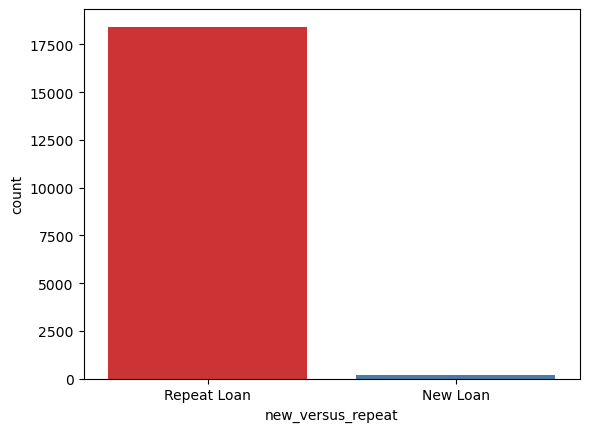

In [46]:
sns.countplot(x='new_versus_repeat', data=df_test, hue= 'new_versus_repeat', palette='Set1')

#### Dates

In [47]:
df_test['due_date'] = pd.to_datetime(df_test['due_date'])

In [48]:
df_test['due_month'] = df_test['due_date'].dt.month

In [49]:
df_test['due_date'] = df_test['due_date'].dt.strftime('%Y-%m-%d')

#### Daily Payment Ratio

In [50]:
# Calculate Daily Payment Ratio
df_test = df_test.copy()
df_test['daily_payment_ratio'] = df_test['total_amount_to_repay'] / df_test['duration']

#### Risk Score

In [52]:
df_test['risk_score'] = np.where(
    (df_test['interest_rate'] < 0) | (df_test['lender_portion_to_be_repaid'] == 0.0),
    0.0,
    (df_test['interest_rate'] * df_test['total_amount_to_repay']) /
    (df_test['duration'] * df_test['lender_portion_to_be_repaid'])
)

#### Testing for multicollinearity

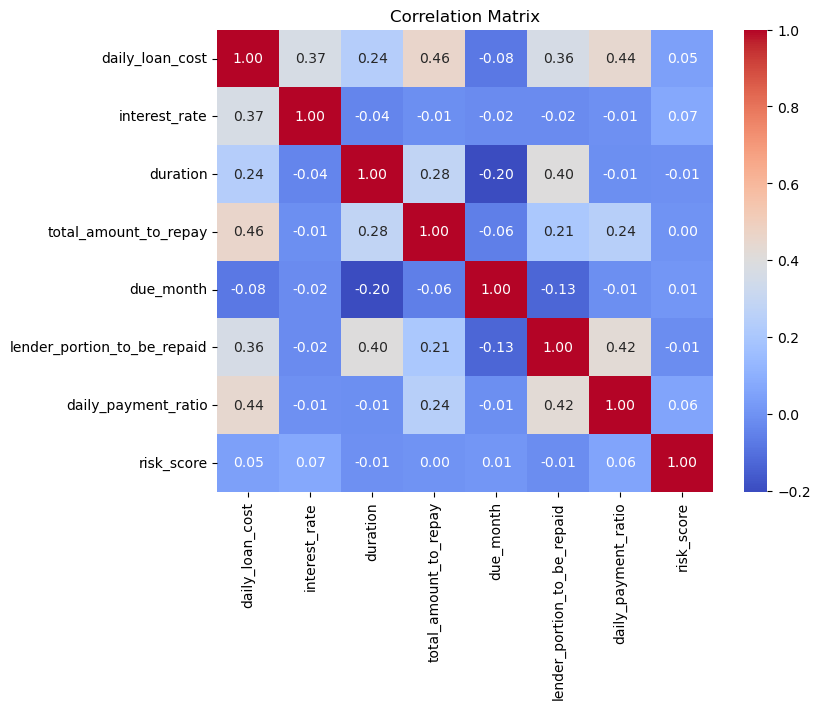

In [53]:
# numerical columns to check the correlation
numerical_columns = ['daily_loan_cost', 'interest_rate', 'duration', 'total_amount_to_repay', 
                     'due_month', 'lender_portion_to_be_repaid', 'daily_payment_ratio', 'risk_score']
correlation_matrix = df_test[numerical_columns].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', cbar=True)
plt.title('Correlation Matrix')
plt.savefig('corr_matrix1.png', dpi=400, bbox_inches='tight' )
plt.show()

In [54]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# Include relevant features
features = ['daily_loan_cost', 'interest_rate', 'duration', 'total_amount_to_repay', 
            'due_month', 'lender_portion_to_be_repaid', 'daily_payment_ratio', 'risk_score']

# Add a constant for VIF calculation
X = add_constant(df_test[features])

# Calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data['Feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif_data)

                       Feature        VIF
0                        const  18.398092
1              daily_loan_cost   2.020198
2                interest_rate   1.305025
3                     duration   1.416629
4        total_amount_to_repay   1.382912
5                    due_month   1.047120
6  lender_portion_to_be_repaid   1.565688
7          daily_payment_ratio   1.568567
8                   risk_score   1.011264


#### Model Building

In [56]:
df_test.columns

Index(['id', 'customer_id', 'country_id', 'tbl_loan_id', 'lender_id',
       'loan_type', 'total_amount', 'total_amount_to_repay', 'interest_rate',
       'disbursement_date', 'due_date', 'duration', 'amount_funded_by_lender',
       'lender_portion_funded', 'lender_portion_to_be_repaid',
       'new_versus_repeat', 'daily_loan_cost', 'due_month',
       'daily_payment_ratio', 'risk_score'],
      dtype='object')

In [57]:
#feature selection
df1_test = df_test[['id', 'loan_type', 'total_amount_to_repay', 'interest_rate', 'duration', 'daily_loan_cost', 'new_versus_repeat', 
                    'due_month', 'lender_portion_to_be_repaid', 'daily_payment_ratio', 'risk_score']]
df1_test.head()

,id,loan_type,total_amount_to_repay,interest_rate,duration,daily_loan_cost,new_versus_repeat,due_month,lender_portion_to_be_repaid,daily_payment_ratio,risk_score
0,ID_269404226088267278,Type_1,1989.0,190.203231,7,10.000000,Repeat Loan,8,597.0,284.142857,90.527453
1,ID_255356300042267278,Type_1,2153.0,36.582921,7,2.142857,Repeat Loan,11,0.0,307.571429,0.000000
2,ID_257026243764267278,Type_1,8304.0,31.586417,7,7.142857,Repeat Loan,8,208.0,1186.285714,180.146708
3,ID_264617299409267278,Type_1,3379.0,0.000000,7,0.000000,Repeat Loan,11,1014.0,482.714286,0.000000
4,ID_247613296713267278,Type_1,120.0,0.000000,7,0.000000,Repeat Loan,11,36.0,17.142857,0.000000


In [58]:
df1_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18594 entries, 0 to 18593
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id                           18594 non-null  object 
 1   loan_type                    18594 non-null  object 
 2   total_amount_to_repay        18594 non-null  float64
 3   interest_rate                18594 non-null  float64
 4   duration                     18594 non-null  int64  
 5   daily_loan_cost              18594 non-null  float64
 6   new_versus_repeat            18594 non-null  object 
 7   due_month                    18594 non-null  int32  
 8   lender_portion_to_be_repaid  18594 non-null  float64
 9   daily_payment_ratio          18594 non-null  float64
 10  risk_score                   18594 non-null  float64
dtypes: float64(6), int32(1), int64(1), object(3)
memory usage: 1.5+ MB


In [59]:
df1_test.to_csv('df1_test.csv')

#### Model Testing

In [60]:
#selecting features for prediction
X_df1_test = df1_test[['loan_type', 'total_amount_to_repay', 'interest_rate', 'duration', 'lender_portion_to_be_repaid', 'due_month', 
                       'daily_loan_cost', 'daily_payment_ratio', 'risk_score', 'new_versus_repeat']]

In [61]:
#loading model
import joblib
loaded_model = joblib.load('rf_final_model.pkl')
with open('optimized_threshold.txt', 'r') as f:
    optimized_threshold = float(f.read())

In [63]:
#predicting probabilities for every transaction
y_proba_test = loaded_model.predict_proba(X_df1_test)[:, 1]

In [65]:
#predicting target values
y_pred_test = (y_proba_test >= optimized_threshold).astype(int)

In [69]:
#preparing submission file
final_submission = pd.DataFrame({
    'id': df1_test['id'],
    'target': y_pred_test
})
print(final_submission.head())

                      id  target
0  ID_269404226088267278       0
1  ID_255356300042267278       0
2  ID_257026243764267278       0
3  ID_264617299409267278       0
4  ID_247613296713267278       0


In [67]:
final_submission.to_csv('Submission_final.csv', index=False)

In [68]:
final_submission.groupby('target').size()

target
0    17862
1      732
dtype: int64